In [8]:
from parcels import (
    AdvectionRK4_3D,
    FieldSet,
    JITParticle,
    ParticleSet,
)

from pathlib import Path
import datetime
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import cartopy
import hvplot.xarray

In [4]:
ds = xr.open_zarr("OCE173-4G_sacculifer_304_00000000000000000000000000000004_.zarr").compute()

/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


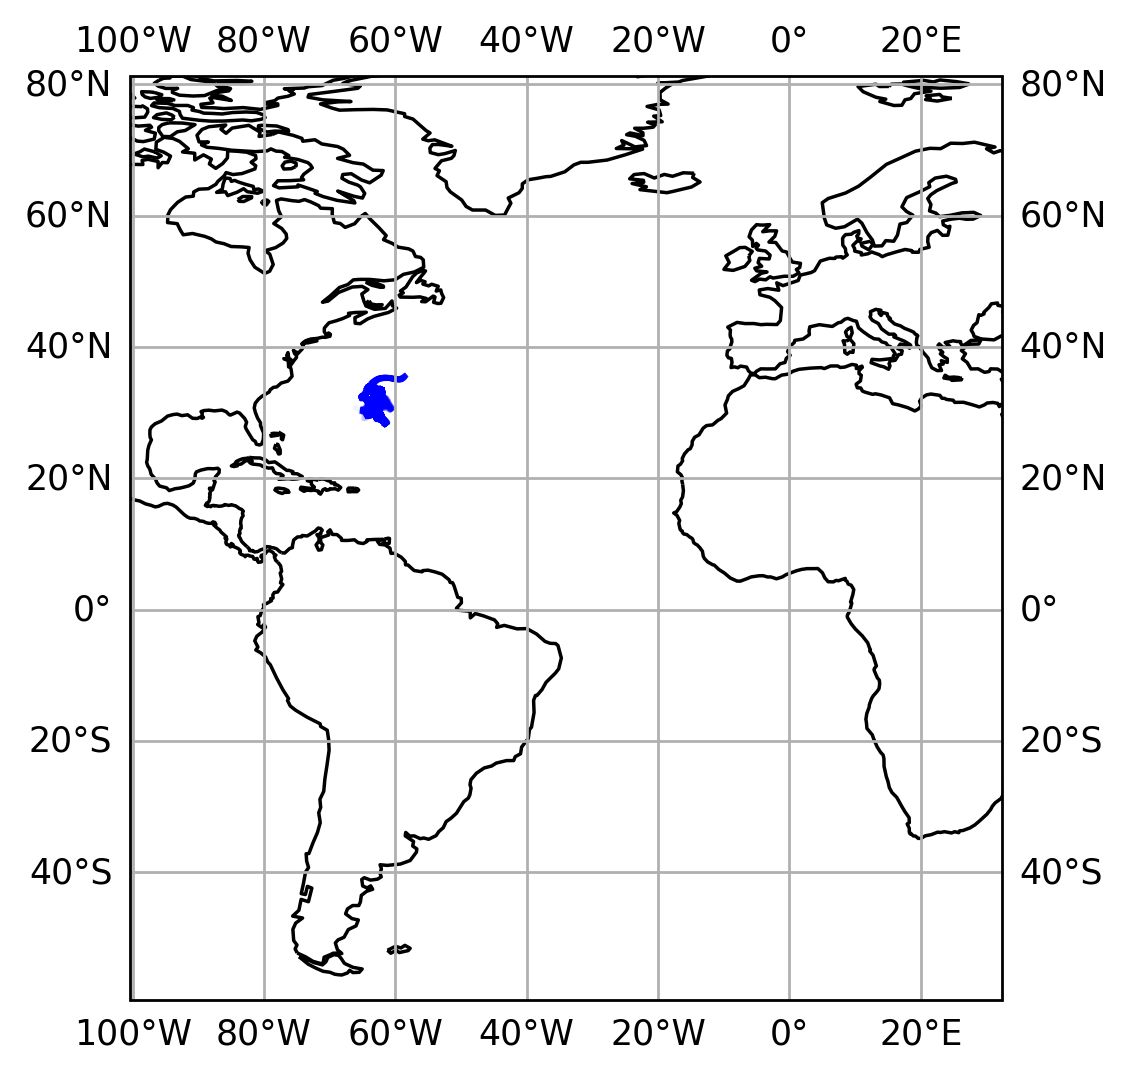

In [3]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": cartopy.crs.PlateCarree()})
fig.set_dpi(250)
for n in range(ds.sizes["trajectory"]):
    ax.plot(
        *ds.isel(trajectory=n)[["lon", "lat"]].dropna("obs").data_vars.values(),
        color="b", alpha=0.05,
        transform=cartopy.crs.PlateCarree(),
    )

ax.coastlines()
ax.set_extent([
    -100.44503,
    32.347466,
    -33.98645,
    69.389336,
])
ax.gridlines(draw_labels=True);

In [4]:
ds

<xarray.Dataset> Size: 10GB
Dimensions:       (trajectory: 910000, obs: 240)
Coordinates:
  * obs           (obs) int32 960B 0 1 2 3 4 5 6 ... 233 234 235 236 237 238 239
  * trajectory    (trajectory) int64 7MB 0 1 2 3 ... 909996 909997 909998 909999
Data variables:
    habDepth      (trajectory, obs) float32 874MB 50.0 50.0 50.0 ... nan nan nan
    lat           (trajectory, obs) float64 2GB 31.9 31.91 31.93 ... nan nan nan
    lon           (trajectory, obs) float64 2GB -64.3 -64.29 -64.28 ... nan nan
    sinkingSpeed  (trajectory, obs) float32 874MB 0.016 0.016 0.016 ... nan nan
    temperature   (trajectory, obs) float32 874MB 1.774 2.08 2.856 ... nan nan
    time          (trajectory, obs) datetime64[ns] 2GB 1994-12-31T09:12:00 .....
    z             (trajectory, obs) float64 2GB 4.469e+03 3.782e+03 ... nan nan
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    habdepth:               50.0
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleSampleTAdvectionRK4_3DActiveSinkingChe...
    parcels_mesh:           spherical
    parcels_version:        3.0.6
    species:                sacculifer
    vsink:                  0.016

In [15]:
ds.isel(trajectory=500000)

<xarray.Dataset> Size: 12kB
Dimensions:       (obs: 240)
Coordinates:
  * obs           (obs) int32 960B 0 1 2 3 4 5 6 ... 233 234 235 236 237 238 239
    trajectory    int64 8B 500000
Data variables:
    habDepth      (obs) float32 960B 50.0 50.0 50.0 50.0 ... nan nan nan nan
    lat           (obs) float64 2kB 31.9 31.91 31.93 31.93 ... nan nan nan nan
    lon           (obs) float64 2kB -64.3 -64.29 -64.27 -64.25 ... nan nan nan
    sinkingSpeed  (obs) float32 960B 0.016 0.016 0.016 0.016 ... nan nan nan nan
    temperature   (obs) float32 960B 1.763 2.006 2.794 3.372 ... nan nan nan nan
    time          (obs) datetime64[ns] 2kB 1994-09-22T09:12:00 ... NaT
    z             (obs) float64 2kB 4.469e+03 3.782e+03 3.095e+03 ... nan nan
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    habdepth:               50.0
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleSampleTAdvectionRK4_3DActiveSinkingChe...
    parcels_mesh:           spherical
    parcels_version:        3.0.6
    species:                sacculifer
    vsink:                  0.016

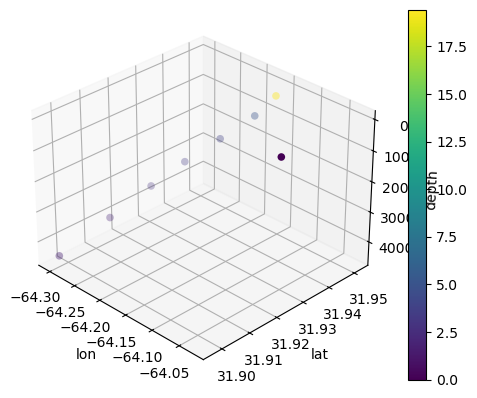

In [14]:
ds2 = ds.isel(trajectory=500000)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
p= ax.scatter(ds2.lon, ds2.lat, ds2.z, c=ds2.temperature, s=30, cmap="viridis", edgecolors="none")
plt.gca().invert_zaxis()
ax.set_xlabel('lon')
ax.set_ylabel('lat')
ax.set_zlabel('depth')
fig.colorbar(p)
ax.view_init(elev=30, azim=-45, roll=0)

plt.show()

In [ ]:
#dframe = ds.to_dataframe()

ds.hvplot.points(
    x=ds["lon"],
    y=ds["lat"],
    c=ds["temperature"],
    geo=True,
    coastline=True,
)